# Analysis of posts by authors

In [2]:
import pandas as pd

## 1. Prepare data

- Convert the date column to datetime format (`pd.datetime`).

In [3]:
df = pd.read_csv("authors_posts.csv")
df["date"] = pd.to_datetime(df["date"])
df.drop(columns=["Unnamed: 0", "authors", "created_at"], inplace=True)
df

,body,title,date,Grasse Hopper,Unammed Unammed,Test TEst,Antonio Pisanello,Test PP ppp,Alan Turing,Test UUID,Test Test
0,Blue change around research school record safe...,Rich discussion practice until go.,2025-04-03,1,1,0,1,0,1,1,1
1,Their cultural sister play might. Purpose able...,Let material increase involve manage.,2025-04-02,1,0,1,1,0,1,1,1
2,Natural mission itself friend. Stand choice wo...,Ask writer environmental writer.,2025-04-05,1,0,1,1,1,1,1,1
3,Low season discover industry let much presiden...,Management condition bad debate catch surface.,2025-04-05,1,1,1,1,1,0,1,1
4,Sort word put type. Cup southern up Congress f...,Draw suffer politics more.,2025-04-04,0,0,0,0,0,0,0,1
5,Agency recent wind man. It move adult however ...,Hear language sea could their guess people.,2025-04-06,0,1,1,1,0,1,1,1
6,Garden them stage think. Former behavior histo...,Camera rise table really pull answer stuff hot.,2025-04-06,0,0,1,1,0,1,1,1
7,How history hope activity operation local face...,Wife late market economic upon.,2025-04-02,0,1,1,1,1,0,0,1
8,Live air outside with. Alone effect less almos...,Five senior after me.,2025-04-08,0,0,1,1,1,1,1,0
9,Hair vote hour team part find. Plan quite shou...,Piece hear strategy ability score ten green.,2025-04-05,0,0,0,0,0,0,0,1


## 2. Analyses the posts per date 

Here we want to show how many posts were made per date.
- `Plot` the number of posts per date.
- `Bar Plot` the number of posts per date.

In [60]:
posts_per_date = df.iloc[:, 2:].set_index("date").sum(axis=1).map(lambda nb_a: int(nb_a > 0)).groupby("date").sum().reset_index(name="count")
posts_per_date


,date,count
0,2025-04-02,4
1,2025-04-03,2
2,2025-04-04,2
3,2025-04-05,3
4,2025-04-06,3
5,2025-04-07,1
6,2025-04-08,3
7,2025-04-09,2


<Axes: xlabel='date'>

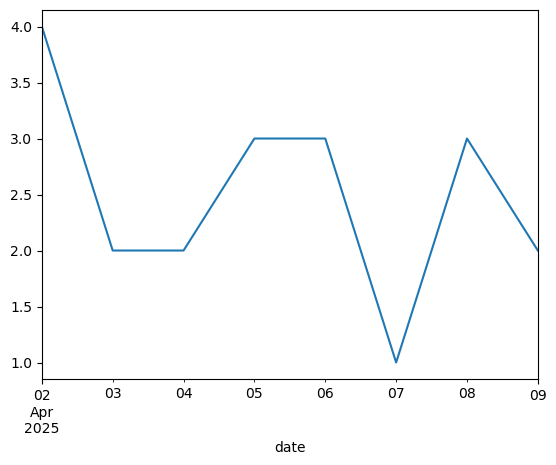

In [7]:
posts_per_date.plot()

<Axes: xlabel='date'>

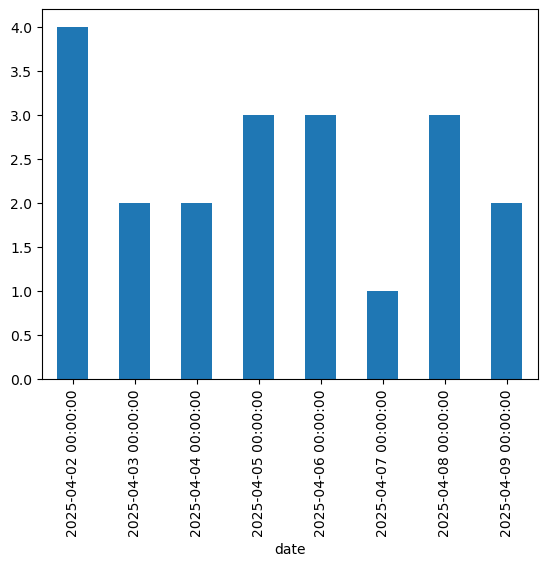

In [8]:
posts_per_date.plot(kind="bar")

## 3. Analyses the posts per author

Here we want to show the number of posts made by each author.
- compute the cumulative sum of posts per author. `cumsum()`
  ![cumsum example](cumsum_result.png)
- `Plot` the dataframe with this command:
  ```python
  df.plot(kind="area", stacked=False, rot=45, figsize=(10, 6), title="Post by Authors", ylabel="Number of posts")
  ```

In [28]:
df.sort_values("date")

,body,title,date,Grasse Hopper,Unammed Unammed,Test TEst,Antonio Pisanello,Test PP ppp,Alan Turing,Test UUID,Test Test
1,Their cultural sister play might. Purpose able...,Let material increase involve manage.,2025-04-02,1,0,1,1,0,1,1,1
10,Consumer trial instead popular during key. Som...,Sound traditional top determine girl way well.,2025-04-02,0,0,0,0,0,1,0,0
18,Degree industry great rise. Care beat finish c...,South consumer lead free cell.,2025-04-02,1,1,1,1,1,1,1,1
7,How history hope activity operation local face...,Wife late market economic upon.,2025-04-02,0,1,1,1,1,0,0,1
0,Blue change around research school record safe...,Rich discussion practice until go.,2025-04-03,1,1,0,1,0,1,1,1
12,Control compare toward say cell plant. Sport f...,Total American field sense southern war.,2025-04-03,1,1,1,1,1,1,0,1
11,Though low condition land time always accordin...,Face head start.,2025-04-04,1,1,0,1,0,0,0,1
4,Sort word put type. Cup southern up Congress f...,Draw suffer politics more.,2025-04-04,0,0,0,0,0,0,0,1
9,Hair vote hour team part find. Plan quite shou...,Piece hear strategy ability score ten green.,2025-04-05,0,0,0,0,0,0,0,1
3,Low season discover industry let much presiden...,Management condition bad debate catch surface.,2025-04-05,1,1,1,1,1,0,1,1


<Axes: title={'center': 'Post by Authors'}, xlabel='date', ylabel='Number of posts'>

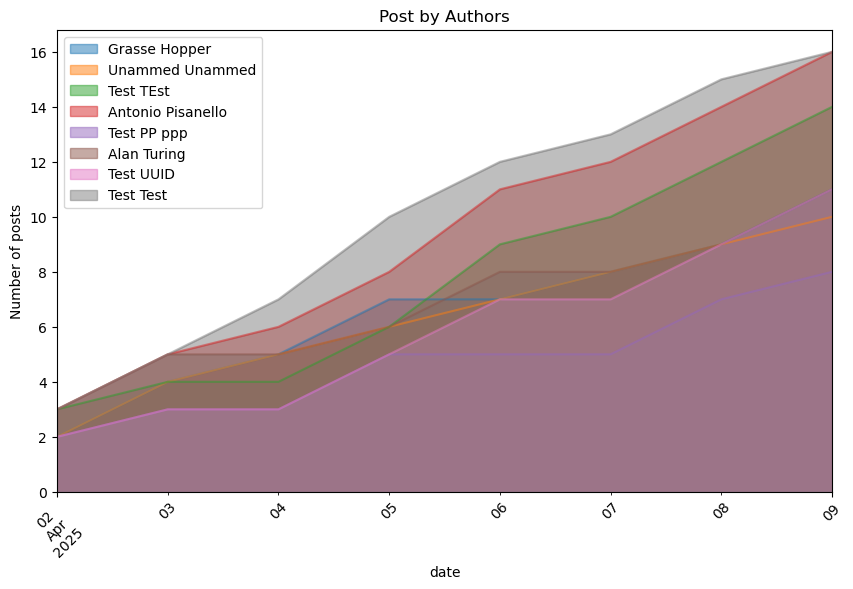

In [35]:
df_authors = df.drop(columns=["body", "title"])
df_authors = df_authors.set_index("date")
df_authors = df_authors.groupby("date").sum().cumsum()
df_authors.plot(kind="area", stacked=False, rot=45, figsize=(10, 6), title="Post by Authors", ylabel="Number of posts")

In [26]:
df_authors.sort_index()

,Grasse Hopper,Unammed Unammed,Test TEst,Antonio Pisanello,Test PP ppp,Alan Turing,Test UUID,Test Test
date,,,,,,,,
2025-04-02,2,2,3,3,2,3,2,3
2025-04-03,2,2,1,2,1,2,1,2
2025-04-04,1,1,0,1,0,0,0,2
2025-04-05,2,1,2,2,2,1,2,3
2025-04-06,0,1,3,3,0,2,2,2
2025-04-07,1,1,1,1,0,0,0,1
2025-04-08,1,1,2,2,2,1,2,2
2025-04-09,2,1,2,2,1,2,2,1
